# Dataset Preparation

## Tokenizer

In [1]:
import pickle
import torch

class WubiCharTokenizer:
    """
    Tokenizes Chinese text into sequences of atomic Wubi symbols (letters + separator).
    Each character becomes a fixed number of tokens (its Wubi code letters + separator).
    No merging across characters occurs.
    """
    def __init__(self, wubi_dict_path):
        with open(wubi_dict_path, 'rb') as f:
            self.ch2wubi = pickle.load(f)

        # Build vocabulary: all possible letters + separator
        self.sep = '#'
        letters = set()
        for code in self.ch2wubi.values():
            letters.update(code)
        # Also include digits? Original mapping strips digits, so just letters.
        self.vocab = ['[PAD]', '[UNK]', self.sep] + sorted(letters)
        self.stoi = {s: i for i, s in enumerate(self.vocab)}
        self.itos = {i: s for s, i in self.stoi.items()}

    def encode(self, text):
        """
        Convert text to a list of token IDs and a list of character spans.
        Returns:
            ids: list of int (token IDs)
            char_spans: list of (start, end) token indices for each character
        """
        text = text.lower()
        ids = []
        char_spans = []
        for ch in text:
            # Get Wubi code (fallback to character itself)
            code = self.ch2wubi.get(ch, ch)
            # Convert each symbol in the code to an ID
            code_ids = [self.stoi.get(c, self.stoi['[UNK]']) for c in code]
            start = len(ids)
            ids.extend(code_ids)
            ids.append(self.stoi[self.sep])
            end = len(ids)
            char_spans.append((start, end))
        return ids, char_spans

    def decode(self, ids):
        """For debugging: convert IDs back to string."""
        return ''.join(self.itos[i] for i in ids if i != self.stoi[self.sep])

In [2]:
# Load the Wubi mapping (from the SubCharTokenization repo)
wubi_dict = "/kaggle/input/notebooks/davidvista/wubi-tokenizer/chinese_to_wubi.pkl"
tokenizer = WubiCharTokenizer(wubi_dict)

text = "我是最高的学生"
ids, spans = tokenizer.encode(text)

print("Token IDs:", ids)
print("Character spans:", spans)
# Output: spans like [(0,5), (5,8), (8,15), ...] depending on code lengths

Token IDs: [29, 2, 22, 2, 22, 14, 2, 37, 25, 2, 30, 2, 21, 28, 2, 32, 19, 2]
Character spans: [(0, 2), (2, 4), (4, 7), (7, 10), (10, 12), (12, 15), (15, 18)]


In [3]:
# Inverse mapping from Wubi to Character
with open("/kaggle/input/notebooks/davidvista/wubi-tokenizer/wubi_to_chinese.pkl", 'rb') as f:
    wubi2ch = pickle.load(f)

## Pinyin Mapper

In [4]:
INITIALS = [
    "", "b","p","m","f","d","t","n","l","g","k","h",
    "j","q","x","zh","ch","sh","r","z","c","s"
]

FINALS = [
    "a","ai","an","ang","ao","e","ei","en","eng","er",
    "i","ia","ian","iang","iao","ie","in","ing","iong","iu",
    "o","ong","ou",
    "u","ua","uai","uan","uang","ui","un","uo",
    "v","ve","van","vn"
]

TONES = ["1","2","3","4","5"]

ZERO_INITIAL_MAP = {
    # y-series
    "yi":"i",
    "ya":"ia",
    "yao":"iao",
    "ye":"ie",
    "you":"iu",
    "yan":"ian",
    "yin":"in",
    "yang":"iang",
    "ying":"ing",
    "yong":"iong",

    "yu":"v",
    "yue":"ve",
    "yuan":"van",
    "yun":"vn",

    # w-series
    "wu":"u",
    "wa":"ua",
    "wo":"uo",
    "wai":"uai",
    "wei":"ui",
    "wan":"uan",
    "wen":"un",
    "wang":"uang",
    "weng":"ong",
}


def normalize_zero_initial(base):
    return ZERO_INITIAL_MAP.get(base, base)


def normalize_jqx(final):
    if final.startswith("u"):
        mapping = {
            "u": "v",
            "ue": "ve",
            "uan": "van",
            "un": "vn",
        }
        return mapping.get(final, final)
    return final


init2idx = {v:i for i,v in enumerate(INITIALS)}
final2idx = {v:i for i,v in enumerate(FINALS)}
tone2idx = {v:i for i,v in enumerate(TONES)}

idx2init = {i:v for v,i in init2idx.items()}
idx2final = {i:v for v,i in final2idx.items()}
idx2tone = {i:v for v,i in tone2idx.items()}


def decompose_pinyin(token: str):
    tone = token[-1]

    if not tone.isdigit():
        tone = "5" # neutral tone, usually has no digit
        base = token
    else:
        base = token[:-1]

    base = normalize_zero_initial(base)

    # longest-match for initials

    try:
        for ini in sorted(INITIALS, key=len, reverse=True):
            if base.startswith(ini):
                final = base[len(ini):]

                if ini in {"j","q","x"}:
                    final = normalize_jqx(final)
                
                return [init2idx[ini], final2idx[final], tone2idx[tone]]
    except Exception:
        raise ValueError("Invalid pinyin token")

## Dataset: Text + Pinyin

In [5]:
import pandas as pd

dataset = pd.read_csv("/kaggle/input/notebooks/davidvista/pinyin-eval-dataset-labelling/eval-chinese-short-sentences-pinyin.csv")

In [6]:
dataset.head()

,text,pinyin
0,他赢了布什说我很高兴是他赢了,ta1 ying2 liao3 bu4 shen2 shuo1 wo3 hen3 gao1 ...
1,你根本想不到有多畅销赛义德说,ni3 gen1 ben3 xiang3 bu4 dao4 you3 duo1 chang4...
2,国家主席是个虚职实权掌握在共产党总书记的手里,guo2 jia1 zhu3 xi2 shi4 ge4 xu1 zhi2 shi2 quan...
3,如果你批评以色列政府有些人会因此说你是反犹主义者,ru2 guo3 ni3 pi1 ping2 yi3 se4 lie4 zheng4 fu3...
4,我是16号下次请还要叫我啊,wo3 shi4 yu2 gu1 hao4 xia4 ci4 qing3 hai2 yao4...


## Dataset: Pinyin Embeddings

In [7]:
import pickle as pkl

with open("/kaggle/input/notebooks/davidvista/mandarin-sounds-dataset/pinyin_embeddings.pkl", "rb") as f:
    embedding_map = pkl.load(f)

In [8]:
embedding_map['wo3'].shape

(1024,)

### PCA of Phonetic Space

In [9]:
import numpy as np


tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)
print(f"Matrix shape: {X.shape}")

Matrix shape: (1102, 1024)


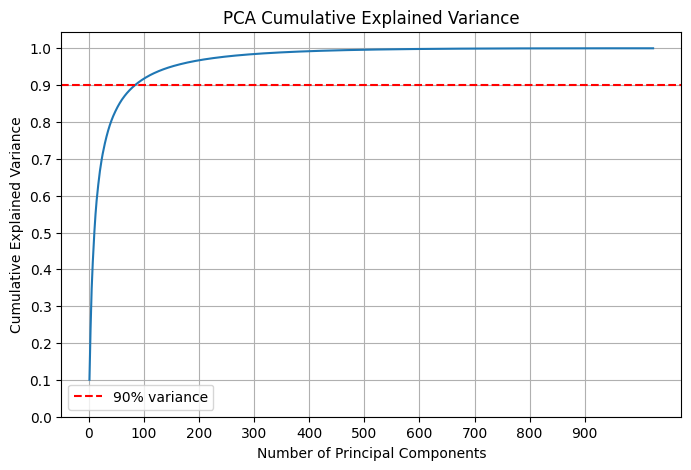

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X)   # optional, if you need components
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.xticks(np.arange(0, 1000, 100))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
K = 100   # number of components to keep
pca = PCA(n_components=K)
X_reduced = pca.fit_transform(X)   # shape (n_samples, K)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance ratio (first {K}): {pca.explained_variance_ratio_.sum():.4f}")

Reduced shape: (1102, 100)
Explained variance ratio (first 100): 0.9176


## Dataset: Semantic Embeddings

### BERT Base Chinese

The BERT Base is chosen as the encoder for semantic representations, the tokenizer is per-

In [12]:
from transformers import AutoTokenizer, AutoModel
import torch

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
bert_model = AutoModel.from_pretrained("bert-base-chinese")

sentence = "你好世界"
inputs = bert_tokenizer(sentence, return_tensors="pt")
with torch.no_grad():
    outputs = bert_model(**inputs)
    # last_hidden_state: (1, seq_len, hidden_dim)
    char_embeddings = outputs.last_hidden_state[0]  # remove batch

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def get_char_embeddings(bert_model, bert_tokenzier, sentence):
    inputs = bert_tokenzier(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Remove [CLS] and [SEP] tokens
    token_embs = outputs.last_hidden_state[0, 1:-1]  # (num_chars, hidden_dim)
    chars = list(sentence)
    return {ch: vec.cpu().numpy() for ch, vec in zip(chars, token_embs)}

In [14]:
for ch, vec in get_char_embeddings(bert_model, bert_tokenizer, '你好世界').items():
    print(ch, vec.shape, vec[:2])

你 (768,) [ 0.2058782 -0.3735184]
好 (768,) [0.48449567 0.08005352]
世 (768,) [0.17610227 0.0756098 ]
界 (768,) [ 0.06911832 -0.44401836]


## Evaluation Dataset

### Filtration

In [15]:
def align(token):
    if token[-1].isalpha():  # e.g. de -> de5
        return token + '5'
    return token

# To see filtered values
dataset[
    dataset['pinyin'].str.split().transform(lambda x: any(align(y) not in embedding_map.keys() for y in x))
]

,text,pinyin
75,纽约时报 突尼斯总统贝吉卡伊德埃塞卜西去世享年92岁,niu3 yue1 shi2 bao4 bu4 tu1 ni2 si1 zong3 tong...
1681,如果我们不能把货运进来就会变得更贵甚至可能要关门售卖黄瓜萝卜和西红柿的小贩左启超音说,ru2 guo3 wo3 men bu4 neng2 ba3 huo4 yun4 jin4 ...
1842,尽管卜蜂莲花与物美善意地进行了广泛的磋商但仍无法就敲定交易中的若干主要条款取得充分进展,jin4 guan3 bo feng1 lian2 hua1 yu3 wu4 mei3 sh...
3415,奥马尔阿卜杜勒拉赫曼可以进世界上任何一个球队踢球阿吉雷,ao4 ma3 er3 a1 bo du4 lei1 la1 he4 man4 ke3 yi...
3933,卜蜂莲花在周一的证交所公告中表示,bo feng1 lian2 hua1 zai4 zhou1 yi1 de zheng4 j...
...,...,...
159314,然而卜威廉的行事方式受到了争议他的一些孩子离开了这个组织,ran2 er2 bo wei1 lian2 de xing2 shi4 fang1 shi...
167619,苦恼于这些被损毁的建筑也得益于社交网络卜冲高虹以及其他一些本地市民集结起来致力于保护哈尔滨还...,ku3 nao3 yu2 zhe4 xie1 bei4 sun3 hui3 de jian4...
169618,试图保护哈尔滨历史建筑的当地居民左起女商人高虹建筑教授卜冲建筑师餐厅老板胡泓,shi4 tu2 bao3 hu4 ha1 er3 bin1 li4 shi3 jian4 ...
170537,谁敢在老城区里做这么大的动作在哈尔滨江边的一家咖啡馆里卜冲质疑为什么高铁不能经过哈尔滨城市中...,shui2 gan3 zai4 lao3 cheng2 qu1 li3 zuo4 zhe4 ...


In [16]:
# Actual filtration
dataset = dataset[
    dataset['pinyin'].str.split().transform(lambda x: all(align(y) in embedding_map.keys() for y in x))
]

In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181432 entries, 0 to 181531
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    181432 non-null  object
 1   pinyin  181432 non-null  object
dtypes: object(2)
memory usage: 4.2+ MB


In [18]:
import re
import pandas as pd

# Unicode range for CJK Unified Ideographs (basic)
# 4E00–9FFF (common), also extensions if needed
hanzi_pattern = re.compile(r'[\u4e00-\u9fff]')

def get_non_hanzi(df):
    """
    Returns a set of all non‑Hanzi characters in the 'text' column.
    """
    non_hanzi = set()
    for text in df['text'].dropna():
        for ch in text:
            if not hanzi_pattern.match(ch):
                non_hanzi.add(ch)
    return non_hanzi

non_hanzi_set = get_non_hanzi(dataset)
print(f"Unique non‑Hanzi characters: {len(non_hanzi_set)}")
print(sorted(non_hanzi_set))

Unique non‑Hanzi characters: 24
[' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '_', 'x', '\xa0', 'Ω', 'β', 'μ', 'τ', '\u2009', '\u2028', 'Ⅱ', 'ー', '㹴', '林']


In [19]:
# To see filtered values
dataset[
    dataset['text'].transform(lambda x: any(y in non_hanzi_set for y in x))
]

,text,pinyin
4,我是16号下次请还要叫我啊,wo3 shi4 yu2 gu1 hao4 xia4 ci4 qing3 hai2 yao4...
7,华尔街日报 西班牙加那利群岛山火肆虐9000人被迫撤离数百名消防员正与火势搏斗,hua2 er3 jie1 ri4 bao4 bu4 xi1 ban1 ya2 jia1 n...
8,南华早报 在14名工作人员被判协助恐怖主义后土耳其主要的独立报纸恢复运作,nan2 hua2 zao3 bao4 lu4 zai4 yu2 ke1 ming2 gon...
12,印度时报 一位双腿截肢的中国男子攀上了珠穆朗玛最高峰,yin4 du4 shi2 bao4 bu4 yi1 wei4 shuang1 tui3 j...
14,朝日新闻 美国官员取消了对制造致命病毒的禁令这将为制造容易感染人类的病原体的争议性研究提供资金,chao2 ri4 xin1 wen2 bu4 mei3 guo2 guan1 yuan2 ...
...,...,...
181475,黎巴嫩哈娜的故事12岁的她有三年时间都过着居无定所的生活,li2 ba1 nen4 ha1 na4 de gu4 shi4 yu2 shou4 sui...
181486,黑客团队的发票显示截至2015年阿联酋是他们的第二大客户仅次于摩洛哥,hei1 ke4 tuan2 dui4 de fa1 piao4 xian3 shi4 ji...
181489,黑山很快将成为第15个国家英国的海外领土安圭拉也计划效仿,hei1 shan1 hen3 kuai4 jiang1 cheng2 wei2 di4 y...
181503,默克尔领导基民盟18年领导德国13年曾被认为是欧洲稳定的压舱石和西方自由秩序的最后捍卫者,mo4 ke4 er3 ling3 dao3 ji1 min2 meng2 yu2 hu2 ...


In [20]:
# Actual filtration
dataset = dataset[
    dataset['text'].transform(lambda x: all(y not in non_hanzi_set for y in x))
]

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152172 entries, 0 to 181531
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    152172 non-null  object
 1   pinyin  152172 non-null  object
dtypes: object(2)
memory usage: 3.5+ MB


### Pinyin Embeddings

In [22]:
import numpy as np
import torch

all_pinyin_tokens = list(embedding_map.keys())

pinyin2idx = {tok: i for i, tok in enumerate(all_pinyin_tokens)}
idx2pinyin = {i: tok for tok, i in pinyin2idx.items()}
embedding_matrix = torch.tensor(X_reduced, dtype=torch.float32)

embedding_matrix.shape

torch.Size([1102, 100])

In [23]:
def get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, pad_idx=-100):
    """
    Args:
        padded_pinyin_idxs: (batch, max_chars) tensor of indices into embedding_matrix, padded with pad_idx
        embedding_matrix: (num_tokens, emb_dim) tensor (on device)
    Returns:
        acoustic_embs: (batch, max_chars, emb_dim) – zero vectors for padded positions
    """
    # Create mask for valid indices
    mask = (padded_pinyin_idxs != pad_idx)
    # Get valid indices
    valid_idxs = padded_pinyin_idxs[mask]  # (num_valid,)
    # Gather embeddings for valid positions
    valid_embs = embedding_matrix[valid_idxs]  # (num_valid, emb_dim)
    # Create output tensor filled with zeros
    batch_size, max_chars = padded_pinyin_idxs.shape
    emb_dim = embedding_matrix.shape[1]
    out = torch.zeros(batch_size, max_chars, emb_dim, device=device)
    # Place valid embeddings at masked positions
    out[mask] = valid_embs
    return out

### Semantic Embeddings

In [24]:
def get_bert_embeddings(padded_char_idxs, bert_model, device, pad_idx=-100):
    # Create attention mask: 1 for real tokens, 0 for padding
    attention_mask = (padded_char_idxs != pad_idx).long().to(device)
    input_ids = padded_char_idxs.to(device)
    # Replace padding value with 0 (BERT uses 0 as [PAD] token id)
    input_ids = input_ids.masked_fill(input_ids == pad_idx, 0)
    with torch.no_grad():
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        # outputs.last_hidden_state: (batch, max_chars, hidden_dim)
        token_embs = outputs.last_hidden_state
        # Each token corresponds to a character (since we removed [CLS]/[SEP])
    return token_embs

### Wubi Tokens

In [25]:
def get_wubi_token_sets(flat_tokens, char_offsets, char_lengths):
    """
    Args:
        flat_tokens: (total_tokens,) tensor of Wubi token IDs
        char_offsets: (total_chars,) start index of each character in flat_tokens
        char_lengths: (batch,) number of characters per sample
    Returns:
        wubi_sets: list of lists of sets (per sample, per character)
    """
    total_chars = len(char_offsets)
    # Convert to numpy for easier indexing
    tokens_np = flat_tokens.cpu().numpy()
    offsets_np = char_offsets.cpu().numpy()
    # Split by sample using char_lengths
    char_offsets_list = []
    start = 0
    for length in char_lengths:
        char_offsets_list.append(offsets_np[start:start+length])
        start += length
    wubi_sets_per_sample = []
    for sample_offsets in char_offsets_list:
        sample_sets = []
        num_chars = len(sample_offsets)
        for i in range(num_chars):
            start_idx = sample_offsets[i]
            # End index: either next start or total tokens
            if i + 1 < num_chars:
                end_idx = sample_offsets[i+1]
            else:
                end_idx = len(tokens_np)
            token_ids = tokens_np[start_idx:end_idx]
            # Exclude separator token if present (optional)
            sample_sets.append(set(token_ids))
        wubi_sets_per_sample.append(sample_sets)
    return wubi_sets_per_sample

### Tokenization

In [26]:
from tqdm import tqdm 

def tokenize_dataset(dataset, tokenizer, pinyin_to_idx):

    for i, sample in tqdm(dataset.iterrows(), total=len(dataset)):
        text = sample['text']
        pinyin_str = sample['pinyin']

        char_seq = list(text)

        pinyin_tokens = pinyin_str.split()
        
        # Valid sample - yield the indices
        token_idxs, char_span = tokenizer.encode(text)

        pinyin_component_idxs = []
        pinyin_idxs = []
        for token in pinyin_tokens:

            try:
                pinyin_component_idx = decompose_pinyin(token)
                pinyin_component_idxs.append(pinyin_component_idx)

                pinyin_idxs.append(pinyin2idx[align(token)])
            except ValueError:
                print(f"Skipped token {token}")

        
        yield char_seq, token_idxs, char_span, pinyin_component_idxs, pinyin_idxs

preprocessed_dataset = tokenize_dataset(dataset, tokenizer, decompose_pinyin)

In [27]:
char_seqs = []
token_seqs = []
char_spans = []
pinyin_seqs = []
pinyin_idx_seqs = []

for char_seq, token_idxs, char_span, pinyin_component_idxs, pinyin_idxs in preprocessed_dataset:
    char_seqs.append(char_seq)
    token_seqs.append(token_idxs)
    char_spans.append(char_span)
    pinyin_seqs.append(pinyin_component_idxs)
    pinyin_idx_seqs.append(pinyin_idxs)

100%|██████████| 152172/152172 [00:33<00:00, 4533.93it/s]


In [28]:
def build_char_vocab(char_seqs, add_pad=True, add_unk=True):
    """
    Build character vocabulary from a list of character sequences.

    Args:
        char_seqs: list of lists of strings (each inner list is a sentence of characters)
        add_pad: if True, include <PAD> token at index 0
        add_unk: if True, include <UNK> token after pad (if pad exists) or at start

    Returns:
        char2idx: dict mapping character to index
        idx2char: list mapping index to character
    """
    # Collect all unique characters
    chars = set()
    for seq in char_seqs:
        for ch in seq:
            chars.add(ch)
    # Sort for deterministic order
    sorted_chars = sorted(chars)

    # Build vocabulary list
    vocab = []
    if add_pad:
        vocab.append('<PAD>')
    if add_unk:
        vocab.append('<UNK>')
    vocab.extend(sorted_chars)

    # Create mappings
    char2idx = {ch: idx for idx, ch in enumerate(vocab)}
    idx2char = vocab

    return char2idx, idx2char

In [29]:
char2idx, idx2char = build_char_vocab(char_seqs)

In [30]:
char_indices = []

for char_sequence in tqdm(char_seqs):
    sentence = ''.join(char_sequence)
    encoded = bert_tokenizer(sentence, return_tensors="pt")
    input_ids = encoded['input_ids'][0]  # (seq_len,)
    # Remove [CLS] (first token) and [SEP] (last token)
    token_ids = input_ids[1:-1].tolist()   # list of integers, same length as len(sentence)
    char_indices.append(token_ids)

100%|██████████| 152172/152172 [00:30<00:00, 4911.66it/s]


In [31]:
char_indices[0]

[800, 6617, 749, 2357, 784, 6432, 2769, 2523, 7770, 1069, 3221, 800, 6617, 749]

### Complete Dataset

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PinyinDataset(Dataset):
    """
    Dataset for character‑to‑pinyin with sub‑character tokens, including raw characters,
    their indices, and pinyin embedding indices.
    """
    def __init__(self, char_sequences, char_indices, token_sequences, char_spans,
                 pinyin_sequences, pinyin_idx_sequences):
        """
        Args:
            char_sequences: list of lists of characters (strings) per sample
            char_indices: list of lists of integer indices for each character
            token_sequences: list of lists of token indices (sub‑character tokens)
            char_spans: list of lists of (start, end) tuples for each character
            pinyin_sequences: list of lists of decomposed pinyin vectors (initial, final, tone)
            pinyin_idx_sequences: list of lists of embedding indices (int) for each character
        """
        assert len(char_sequences) == len(char_indices) == len(token_sequences) == len(char_spans) == len(pinyin_sequences) == len(pinyin_idx_sequences)
        self.char_seqs = char_sequences
        self.char_idxs = char_indices
        self.token_seqs = token_sequences
        self.char_spans = char_spans
        self.pinyin_seqs = pinyin_sequences
        self.pinyin_idx_seqs = pinyin_idx_sequences

    def __len__(self):
        return len(self.token_seqs)

    def __getitem__(self, idx):
        return {
            'chars': self.char_seqs[idx],
            'char_idxs': torch.tensor(self.char_idxs[idx], dtype=torch.long),
            'tokens': torch.tensor(self.token_seqs[idx], dtype=torch.long),
            'offsets': torch.tensor([span[0] for span in self.char_spans[idx]], dtype=torch.long),
            'pinyin': torch.tensor(self.pinyin_seqs[idx], dtype=torch.long),      # (num_chars, 3)
            'pinyin_idx': torch.tensor(self.pinyin_idx_seqs[idx], dtype=torch.long) # (num_chars,)
        }

In [33]:
def collate_fn(batch, pad_idx=-100):
    """
    Collate a batch: flatten tokens, build offsets, and collect character lists, indices,
    pinyin component targets, and pinyin embedding indices.
    Returns:
        flat_tokens: (total_tokens,) concatenated token IDs
        char_offsets: (total_chars,) start index of each character in flat_tokens
        char_lengths: (batch,) number of characters per sample
        padded_pinyin: (batch, max_chars, 3) padded pinyin component targets
        chars_list: list of lists of characters (one per sample)
        padded_char_idxs: (batch, max_chars) padded character indices
        padded_pinyin_idxs: (batch, max_chars) padded pinyin embedding indices
    """
    chars_list = [item['chars'] for item in batch]
    char_idxs_list = [item['char_idxs'] for item in batch]
    tokens_list = [item['tokens'] for item in batch]
    offsets_list = [item['offsets'] for item in batch]
    pinyin_list = [item['pinyin'] for item in batch]
    pinyin_idx_list = [item['pinyin_idx'] for item in batch]

    flat_tokens = []
    char_offsets = []
    char_lengths = []
    total_tokens = 0

    for sample_tokens, sample_offsets in zip(tokens_list, offsets_list):
        flat_tokens.extend(sample_tokens.tolist())
        num_chars = len(sample_offsets)
        char_lengths.append(num_chars)
        for i in range(num_chars):
            char_offsets.append(total_tokens + sample_offsets[i].item())
        total_tokens += len(sample_tokens)

    flat_tokens = torch.tensor(flat_tokens, dtype=torch.long)
    char_offsets = torch.tensor(char_offsets, dtype=torch.long)
    char_lengths = torch.tensor(char_lengths, dtype=torch.long)

    padded_pinyin = nn.utils.rnn.pad_sequence(pinyin_list, batch_first=True,
                                              padding_value=pad_idx)
    padded_char_idxs = nn.utils.rnn.pad_sequence(char_idxs_list, batch_first=True,
                                                 padding_value=pad_idx)
    padded_pinyin_idxs = nn.utils.rnn.pad_sequence(pinyin_idx_list, batch_first=True,
                                                   padding_value=pad_idx)

    return (flat_tokens, char_offsets, char_lengths, padded_pinyin, chars_list,
            padded_char_idxs, padded_pinyin_idxs)

In [34]:
PAD_IDX = -100
BATCH_SIZE = 32

complete_dataset = PinyinDataset(
    char_seqs, char_indices, token_seqs, char_spans,
    pinyin_seqs, pinyin_idx_seqs
)

eval_loader = DataLoader(
    complete_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, PAD_IDX)
)

# Model Preparation

## Encoder Architecture

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class ClassifierHead(nn.Module):
    """MLP with one hidden layer for classification."""
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class Encoder(nn.Module):
    """
    BiLSTM model for predicting pinyin from characters.
    - Token embeddings aggregated per character (EmbeddingBag).
    - Character representations passed through BiLSTM.
    - Three MLP heads predict initial, final, and tone.
    """
    def __init__(self, vocab_size_tokens, embedding_dim, hidden_dim,
                 num_initials, num_finals, num_tones,
                 num_layers=2, dropout=0.3, mlp_hidden_dim=128):
        super().__init__()
        self.embedding_bag = nn.EmbeddingBag(vocab_size_tokens, embedding_dim,
                                              mode='mean')
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

        # MLP heads (input = hidden_dim*2 from BiLSTM)
        self.initial_head = ClassifierHead(hidden_dim * 2, mlp_hidden_dim, num_initials, dropout)
        self.final_head   = ClassifierHead(hidden_dim * 2, mlp_hidden_dim, num_finals, dropout)
        self.tone_head    = ClassifierHead(hidden_dim * 2, mlp_hidden_dim, num_tones, dropout)

    def forward(self, token_ids, token_offsets, char_lengths, return_hidden=False):
        """
        Args:
            token_ids: (total_tokens,) flattened token IDs (no padding)
            token_offsets: (total_chars,) start indices for each character
            char_lengths: (batch,) number of characters per sample
            return_hidden: if True, also return character‑level hidden states
        Returns:
            logits_initial, logits_final, logits_tone:
                each shape (batch, max_char_len, respective_vocab_size)
            (optional) char_out: (batch, max_char_len, hidden_dim*2) before heads
        """
        char_emb = self.embedding_bag(token_ids, token_offsets)  # (total_chars, emb_dim)

        # Split into per‑sample sequences and pad
        char_emb_list = torch.split(char_emb, char_lengths.tolist())
        padded_char_emb = nn.utils.rnn.pad_sequence(char_emb_list, batch_first=True)

        # Pack for LSTM
        packed_emb = pack_padded_sequence(padded_char_emb, char_lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_emb)
        char_out, _ = pad_packed_sequence(packed_out, batch_first=True)
        char_out = self.dropout(char_out)

        # Three MLP heads
        logits_initial = self.initial_head(char_out)
        logits_final   = self.final_head(char_out)
        logits_tone    = self.tone_head(char_out)

        if return_hidden:
            return logits_initial, logits_final, logits_tone, char_out
        return logits_initial, logits_final, logits_tone

In [36]:
vocab_size_tokens = len(tokenizer.vocab)
embedding_dim = 100
hidden_dim = 512
mlp_hidden_dim = 256
num_initials = len(init2idx)
num_finals   = len(final2idx)
num_tones    = len(tone2idx)
num_layers = 4

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Create model instance
encoder = Encoder(
    vocab_size_tokens=vocab_size_tokens,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    mlp_hidden_dim=mlp_hidden_dim,
    num_initials=num_initials,
    num_finals=num_finals,
    num_tones=num_tones,
    num_layers=num_layers
).to(device)

## Loading Model

In [37]:
encoder.load_state_dict(torch.load('/kaggle/input/full-pipeline-encoders/wubi_encoder_finetuned.pt', map_location=device))
encoder.eval()

print("Loaded encoder successfully!")

Loaded encoder successfully!


In [38]:
bert_model = bert_model.to(device)

In [39]:
embedding_matrix = embedding_matrix.to(device)

## Hooking Function

In [40]:
def get_hidden_states(flat_tokens, char_offsets, char_lengths, encoder, device):
    with torch.no_grad():
        *_, hidden = encoder(flat_tokens, char_offsets, char_lengths, return_hidden=True)
        # hidden: (batch, max_chars, hidden_dim*2)
    return hidden

# Extraction

## Basic Loop

In [41]:
for batch in eval_loader:
    (flat_tokens, char_offsets, char_lengths, padded_pinyin, chars_list,
     padded_char_idxs, padded_pinyin_idxs) = batch

    flat_tokens = flat_tokens.to(device)
    char_offsets = char_offsets.to(device)
    char_lengths = char_lengths.to(device)
    padded_pinyin = padded_pinyin.to(device)
    padded_pinyin_idxs = padded_pinyin_idxs.to(device)

    hidden_states = get_hidden_states(flat_tokens, char_offsets, char_lengths, encoder, device)
    acoustic_embs = get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, PAD_IDX)
    semantic_embs = get_bert_embeddings(padded_char_idxs, bert_model, device, PAD_IDX)
    wubi_sets = get_wubi_token_sets(flat_tokens, char_offsets, char_lengths)
    
    for b in range(len(chars_list)):
        chars = chars_list[b]
        num_chars = char_lengths[b].item()

        # Get pinyin components for this sample (first num_chars)
        pinyin_components = padded_pinyin[b, :num_chars].cpu().numpy()  # (num_chars, 3)
        wubi_sets_sample = wubi_sets[b]   # list of sets

        for i, ch in enumerate(chars[:num_chars]):
            hidden_vec = hidden_states[b, i].cpu().numpy()
            acoustic_vec = acoustic_embs[b, i].cpu().numpy()
            semantic_vec = semantic_embs[b, i].cpu().numpy()
            wubi_set = wubi_sets_sample[i]
            pinyin_comp = pinyin_components[i]
            print(ch, hidden_vec.shape, acoustic_vec.shape, semantic_vec.shape, wubi_set, pinyin_comp)
            break
        break
    break

他 (1024,) (100,) (768,) {np.int64(2), np.int64(35), np.int64(14)} [6 0 0]


## Aggregation Over Contexts

In [42]:
from collections import defaultdict
import numpy as np
from tqdm import tqdm

# Initialize storage
aggregated = defaultdict(lambda: {
    'hidden_sum': None,
    'semantic_sum': None,
    'count': 0,
    'wubi_set': None,
    'acoustic_vec': None,
    'pinyin_components': None
})

for batch in tqdm(eval_loader, desc="Processing batches"):
    (flat_tokens, char_offsets, char_lengths, padded_pinyin, chars_list,
     padded_char_idxs, padded_pinyin_idxs) = batch

    flat_tokens = flat_tokens.to(device)
    char_offsets = char_offsets.to(device)
    char_lengths = char_lengths.to(device)
    padded_pinyin = padded_pinyin.to(device)
    padded_pinyin_idxs = padded_pinyin_idxs.to(device)

    hidden_states = get_hidden_states(flat_tokens, char_offsets, char_lengths, encoder, device)
    acoustic_embs = get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, PAD_IDX)
    semantic_embs = get_bert_embeddings(padded_char_idxs, bert_model, device, PAD_IDX)
    wubi_sets = get_wubi_token_sets(flat_tokens, char_offsets, char_lengths)

    for b in range(len(chars_list)):
        chars = chars_list[b]
        num_chars = char_lengths[b].item()
        pinyin_components = padded_pinyin[b, :num_chars].cpu().numpy()
        wubi_sets_sample = wubi_sets[b]

        for i in range(num_chars):
            ch = chars[i]
            pinyin_idx = padded_pinyin_idxs[b, i].item()
            pinyin_token = idx2pinyin[pinyin_idx]
            key = (ch, pinyin_token)

            agg = aggregated[key]
            # Update sums
            if agg['hidden_sum'] is None:
                agg['hidden_sum'] = hidden_states[b, i].cpu().numpy()
                agg['semantic_sum'] = semantic_embs[b, i].cpu().numpy()
                agg['wubi_set'] = wubi_sets_sample[i]
                agg['acoustic_vec'] = acoustic_embs[b, i].cpu().numpy()
                agg['pinyin_components'] = pinyin_components[i]
            else:
                agg['hidden_sum'] += hidden_states[b, i].cpu().numpy()
                agg['semantic_sum'] += semantic_embs[b, i].cpu().numpy()
            agg['count'] += 1

# After processing all batches, compute averages
aggregated_results = {}
for key, data in tqdm(aggregated.items(), desc="Averaging"):
    hidden_avg = data['hidden_sum'] / data['count']
    semantic_avg = data['semantic_sum'] / data['count']
    aggregated_results[key] = {
        'hidden': hidden_avg,
        'semantic': semantic_avg,
        'wubi_set': data['wubi_set'],
        'acoustic': data['acoustic_vec'],
        'pinyin_components': data['pinyin_components'],
        'count': data['count']
    }

print(f"Aggregated {len(aggregated_results)} distinct (character, pinyin) pairs.")

Averaging: 100%|██████████| 11507/11507 [00:00<00:00, 92062.67it/s]

Aggregated 11507 distinct (character, pinyin) pairs.


In [43]:
import joblib

joblib.dump(aggregated_results, 'aggregated_records.joblib')

['aggregated_records.joblib']

## Context Dependent Records

In [44]:
from torch.utils.data import DataLoader, Subset
import random

# Set seed for reproducibility
random.seed(0)

total = len(complete_dataset)
sample_size = 10000
indices = random.sample(range(total), sample_size)
sampled_dataset = Subset(complete_dataset, indices)

sample_eval_loader = DataLoader(
    sampled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, PAD_IDX)
)

In [45]:
import numpy as np
from tqdm import tqdm

# Create inverse mapping from embedding index to pinyin string
idx2pinyin = {v: k for k, v in pinyin2idx.items()}

records = []  # list of dicts, one per character occurrence

for batch in tqdm(sample_eval_loader, desc="Extracting representations"):
    (flat_tokens, char_offsets, char_lengths, padded_pinyin, chars_list,
     padded_char_idxs, padded_pinyin_idxs) = batch

    flat_tokens = flat_tokens.to(device)
    char_offsets = char_offsets.to(device)
    char_lengths = char_lengths.to(device)
    padded_pinyin = padded_pinyin.to(device)
    padded_pinyin_idxs = padded_pinyin_idxs.to(device)

    # Move tensors to device if not already (assuming they are on device)
    hidden_states = get_hidden_states(flat_tokens, char_offsets, char_lengths, encoder, device)
    acoustic_embs = get_acoustic_embeddings(padded_pinyin_idxs, embedding_matrix, device, PAD_IDX)
    semantic_embs = get_bert_embeddings(padded_char_idxs, bert_model, device, PAD_IDX)
    wubi_sets = get_wubi_token_sets(flat_tokens, char_offsets, char_lengths)

    for b in range(len(chars_list)):
        chars = chars_list[b]
        num_chars = char_lengths[b].item()
        pinyin_components = padded_pinyin[b, :num_chars].cpu().numpy()  # (num_chars, 3)
        wubi_sets_sample = wubi_sets[b]  # list of sets

        for i in range(num_chars):
            ch = chars[i]
            pinyin_idx = padded_pinyin_idxs[b, i].item()
            pinyin_token = idx2pinyin[pinyin_idx]  # string like "ma1"

            record = {
                'char': ch,
                'pinyin': pinyin_token,
                'hidden': hidden_states[b, i].cpu().numpy(),
                'acoustic': acoustic_embs[b, i].cpu().numpy(),
                'semantic': semantic_embs[b, i].cpu().numpy(),
                'wubi_set': wubi_sets_sample[i],
                'pinyin_components': pinyin_components[i]  # [init_idx, final_idx, tone_idx]
            }
            records.append(record)

print(f"Collected {len(records)} character occurrences.")
unique_keys = set((rec['char'], rec['pinyin']) for rec in records)
print(f"Distinct (character, pinyin) pairs: {len(unique_keys)}")

Extracting representations: 100%|██████████| 313/313 [01:17<00:00,  4.06it/s]

Collected 290350 character occurrences.
Distinct (character, pinyin) pairs: 4866


In [46]:
import joblib

joblib.dump(records, 'character_records.joblib')

['character_records.joblib']